In [1]:
import sys
sys.path.append("../src")

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import albumentations as A
from albumentations.pytorch import ToTensorV2

import config
from model import build_model

In [ ]:
pth_model = '../../checkpoints/best_model.pth'
pth_data = ''

In [3]:
# ── Load model ──────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = build_model(
    in_channels=config.IN_CHANNELS,
    num_classes=config.NUM_CLASSES,
    variant=config.CONVNEXT_VARIANT,
    pretrained=False,
).to(device)

ckpt = torch.load(pth_model, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"Loaded checkpoint from epoch {ckpt['epoch']}  |  val_dice={ckpt['val_dice']:.4f}")

Loaded checkpoint from epoch 38  |  val_dice=0.6381


In [4]:
# ── Load tiles ──────────────────────────────────────────────────
data = np.load(pth_data)
images = data["he"]    # (N, H, W, 3) uint8
masks  = data["masks"] # (N, H, W)    uint8

print(f"Dataset: {len(images)} tiles,  image shape={images.shape[1:]},  mask unique={np.unique(masks)}")

# ── Pick a few tile indices to visualise ────────────────────────
NUM_TILES = 6
rng = np.random.default_rng(seed=42)
indices = rng.choice(len(images), size=NUM_TILES, replace=False)
print("Visualising tile indices:", indices)

Dataset: 1000 tiles,  image shape=(1024, 1024, 3),  mask unique=[0 1 2 3 4 5 6 7 8 9]
Visualising tile indices: [652 770 432 858 438  88]


In [5]:
# ── Colour map — one colour per class (class 0 / background = black) ──
COLORS = [
    "#000000",  # 0 background
    "#e6194b",  # 1
    "#3cb44b",  # 2
    "#4363d8",  # 3
    "#f58231",  # 4
    "#911eb4",  # 5
    "#42d4f4",  # 6
    "#f032e6",  # 7
    "#bfef45",  # 8
    "#fabed4",  # 9
]
cmap = ListedColormap(COLORS[: config.NUM_CLASSES])

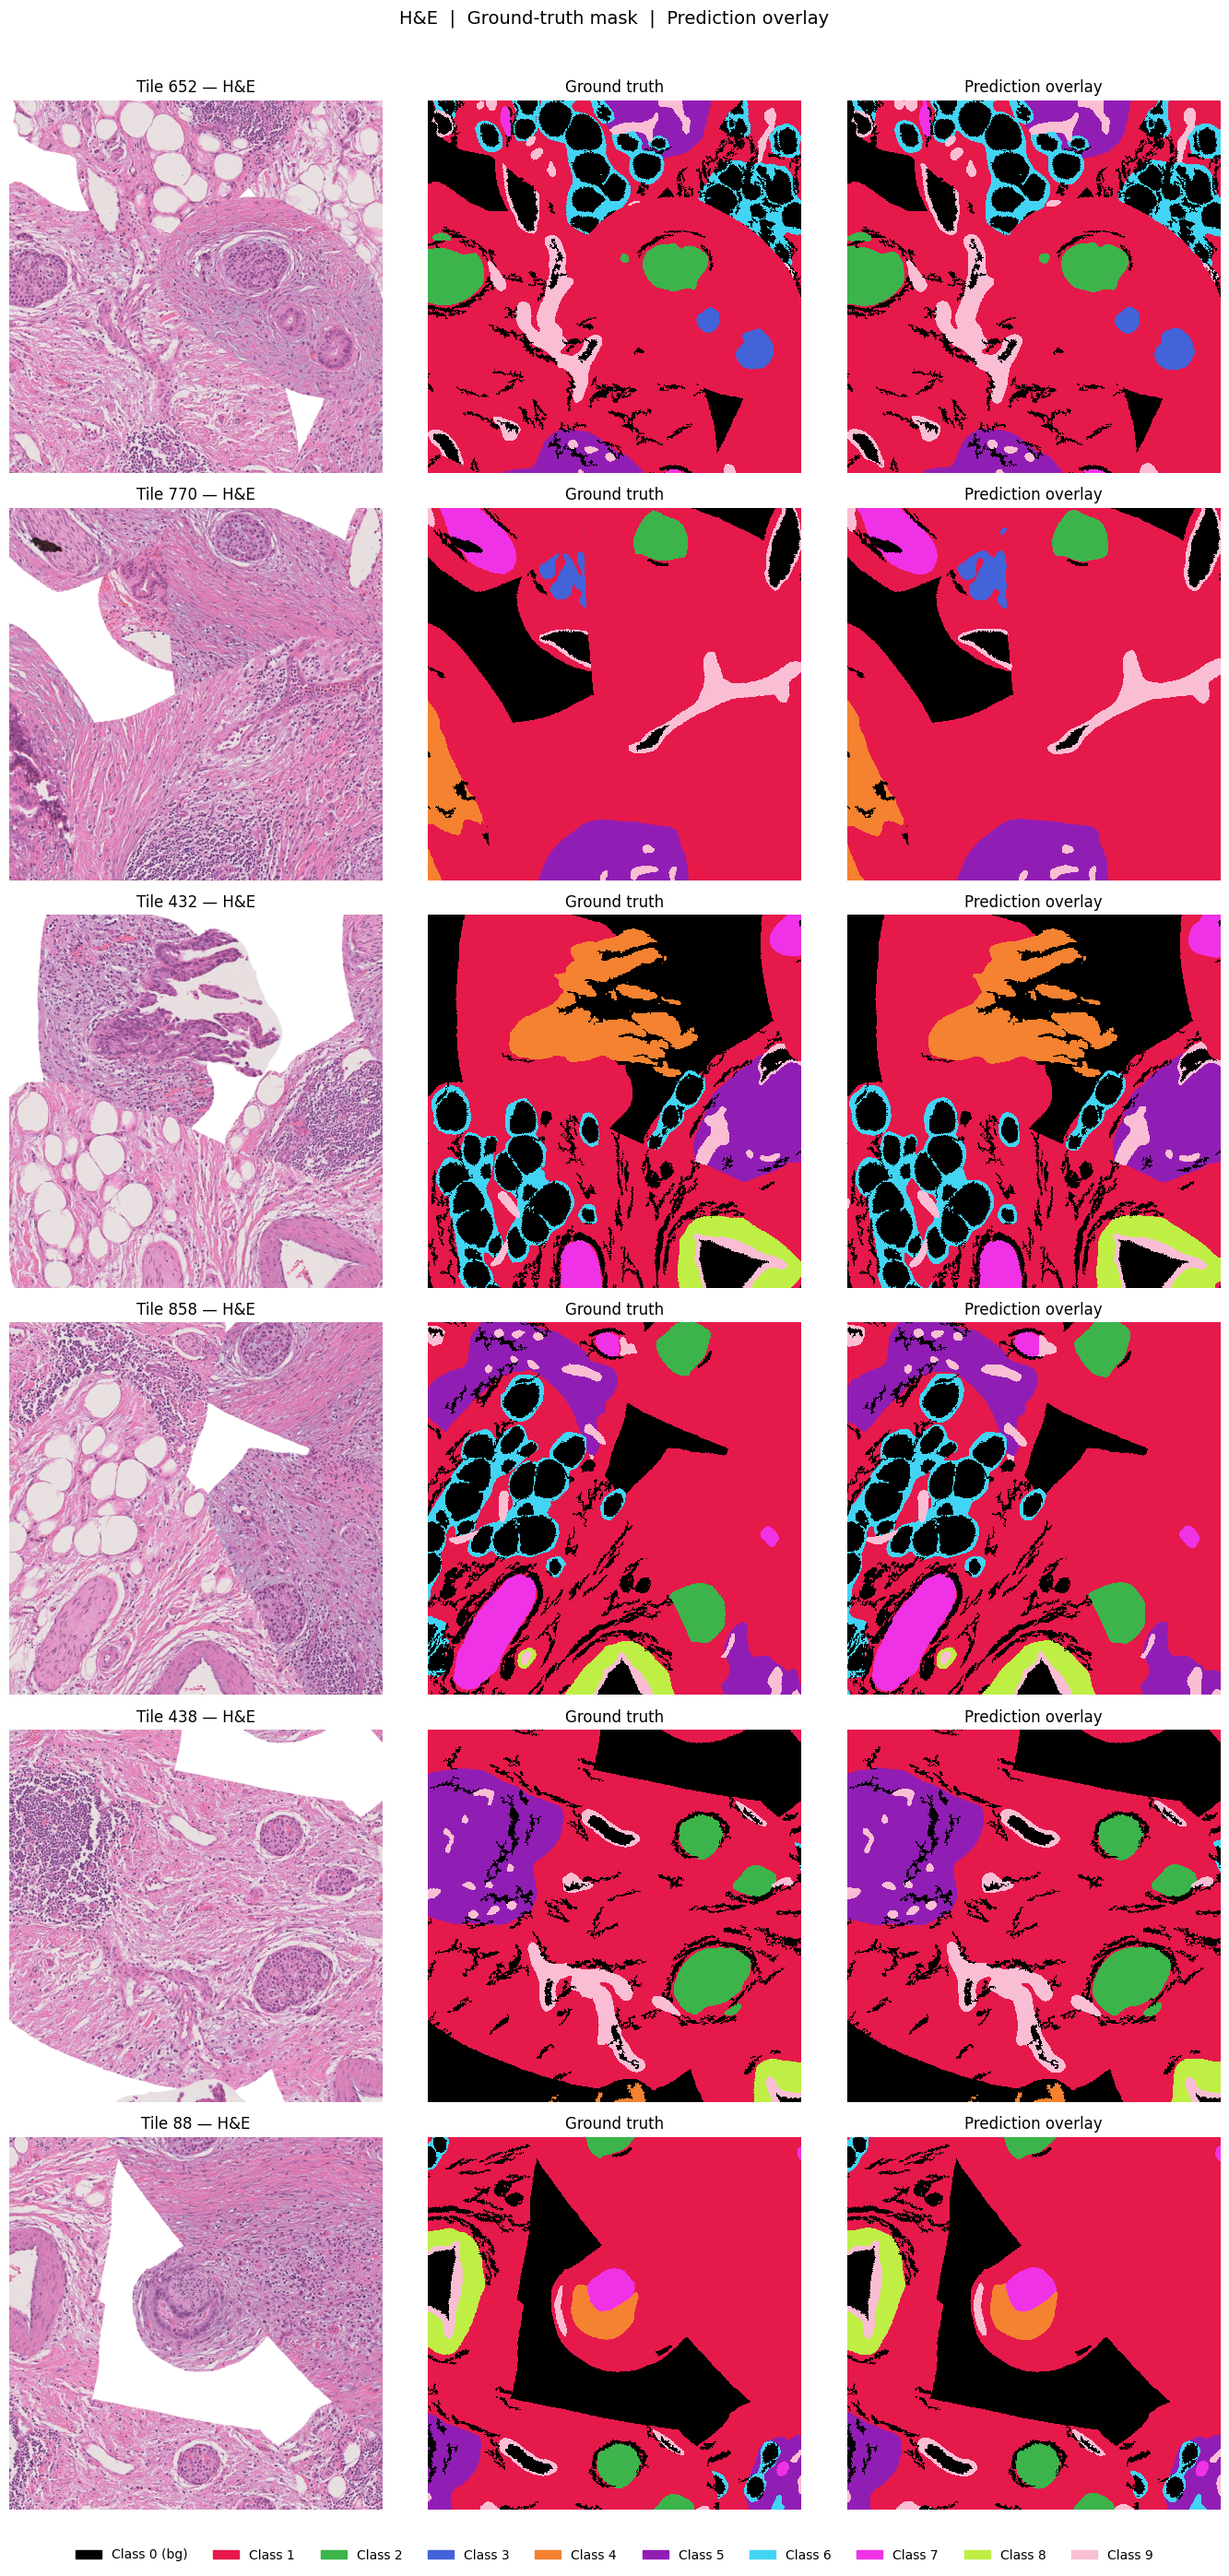

In [8]:
# ── Inference helper ────────────────────────────────────────────
preprocess = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

@torch.no_grad()
def predict(image_np: np.ndarray) -> np.ndarray:
    """image_np: (H, W, 3) uint8  →  pred: (H, W) int"""
    tensor = preprocess(image=image_np)["image"].unsqueeze(0).to(device)
    logits = model(tensor)               # (1, C, H, W)
    pred   = logits.argmax(dim=1).squeeze(0).cpu().numpy()
    return pred

def overlay(image_np, pred, alpha=0.45):
    """Blend prediction colormap over the H&E image."""
    h, w = pred.shape
    colour_mask = np.zeros((h, w, 4), dtype=np.float32)
    for c in range(config.NUM_CLASSES):
        rgb = tuple(int(COLORS[c].lstrip("#")[i:i+2], 16) / 255.0 for i in (0, 2, 4))
        colour_mask[pred == c, :3] = rgb
        colour_mask[pred == c,  3] = 0.0 if c == 0 else alpha  # background fully transparent
    base = image_np.astype(np.float32) / 255.0
    out  = base.copy()
    fg   = colour_mask[..., 3:4]
    out  = base * (1 - fg) + colour_mask[..., :3] * fg
    return np.clip(out, 0, 1)

# ── Plot ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(NUM_TILES, 3, figsize=(14, NUM_TILES * 4.5))
fig.suptitle("H&E  |  Ground-truth mask  |  Prediction overlay", fontsize=14, y=1.01)

legend_patches = [
    mpatches.Patch(color=COLORS[c], label=f"Class {c}" + (" (bg)" if c == 0 else ""))
    for c in range(config.NUM_CLASSES)
]

for row, idx in enumerate(indices):
    img  = images[idx]          # (H, W, 3) uint8
    gt   = masks[idx]           # (H, W)
    pred = predict(img)         # (H, W)

    # artificially make gt background pred background
    pred[gt==0] = 0

    ax_img, ax_gt, ax_pred = axes[row]

    ax_img.imshow(img)
    ax_img.set_title(f"Tile {idx} — H&E")
    ax_img.axis("off")

    ax_gt.imshow(gt, cmap=cmap, vmin=0, vmax=config.NUM_CLASSES - 1, interpolation="nearest")
    ax_gt.set_title("Ground truth")
    ax_gt.axis("off")

    ax_pred.imshow(pred, cmap=cmap, vmin=0, vmax=config.NUM_CLASSES - 1, interpolation="nearest")
    #ax_pred.imshow(overlay(img, pred))
    ax_pred.set_title("Prediction overlay")
    ax_pred.axis("off")

fig.legend(handles=legend_patches, loc="lower center", ncol=config.NUM_CLASSES,
           bbox_to_anchor=(0.5, -0.02), frameon=False)
plt.tight_layout()
#plt.savefig("tile_predictions.png", dpi=150, bbox_inches="tight")
plt.show()
#print("Saved → tile_predictions.png")

In [ ]:
from PIL import Image
import numpy as np

Image.MAX_IMAGE_PIXELS = None  # Disable DecompressionBombError for large images

im = Image.open('')
im = np.array(im)

In [13]:
im.shape

(26752, 31680, 3)

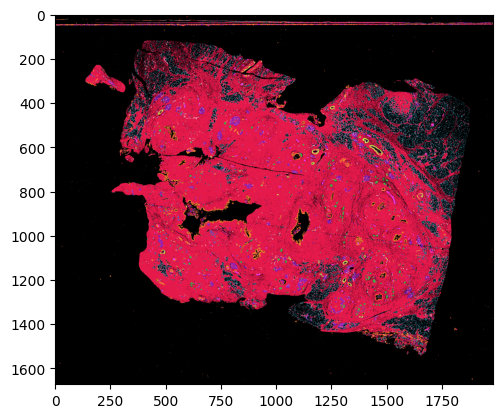

In [15]:
import matplotlib.pyplot as plt

plt.imshow(im[::16,::16,:])

In [ ]:
from tifffile import imwrite

imwrite('', im)